# 🤖 Comparaison des Modèles d'Embedding

Objectif : comparer l'accuracy et la fairness de 5 modèles transformer utilisés comme feature extractor (RF constant).

In [1]:
# Cellule 1: Setup
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Répertoire de travail
if os.path.basename(os.getcwd()) != 'experiments':
    if os.path.exists(os.path.join(os.getcwd(), 'experiments')):
        os.chdir(os.path.join(os.getcwd(), 'experiments'))
print(f'📁 Répertoire: {os.getcwd()}')

CACHE_DIR = Path('embedding_cache')
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'⚡ Device: {DEVICE}')


/Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📁 Répertoire: /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments
⚡ Device: mps


In [2]:
# Cellule 2: Charger données et label encoder
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): data.append(json.loads(line))
    return data

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))

X_train_raw = df_train['full_text'].fillna('').tolist()
X_test_raw  = df_test['full_text'].fillna('').tolist()
y_train = le.transform(df_train['title'])
y_test  = le.transform(df_test['title'])
genders = df_test['gender'].values

print(f'✅ Train: {len(df_train)} | Test: {len(df_test)}')
print(f'📋 Classes: {list(le.classes_)}')


✅ Train: 8000 | Test: 1000
📋 Classes: [np.str_('dentist'), np.str_('nurse'), np.str_('physician'), np.str_('psychologist'), np.str_('surgeon')]


## 🔧 Extraction des Embeddings

In [3]:
# Cellule 3: Fonction d'extraction avec cache disque
def extract_embeddings(texts, model_name, batch_size=32, max_length=128):
    """Extrait les embeddings [CLS] d'un modèle transformer. Cache sur disque."""
    safe_name = model_name.replace('/', '_')
    cache_path = CACHE_DIR / f'{safe_name}_{len(texts)}.npy'

    if cache_path.exists():
        print(f'  📦 Cache trouvé: {cache_path.name}')
        return np.load(cache_path)

    print(f'  🔄 Extraction avec {model_name}...')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(DEVICE)
    model.eval()

    all_embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc='Batches'):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True,
                                max_length=max_length, return_tensors='pt').to(DEVICE)
            output = model(**encoded)
            # Token [CLS] = index 0 du dernier hidden state
            cls_embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_embeddings)

    embeddings = np.vstack(all_embeddings)
    np.save(cache_path, embeddings)
    print(f'  ✅ Sauvegardé: {cache_path.name} — shape: {embeddings.shape}')

    # Libérer la mémoire GPU/MPS
    del model, tokenizer
    if DEVICE != 'cpu': torch.cuda.empty_cache() if DEVICE == 'cuda' else None

    return embeddings

print('✅ Fonction extract_embeddings prête')


✅ Fonction extract_embeddings prête


## 📊 Métriques de Fairness

In [4]:
# Cellule 4: Fonctions fairness (paramétrées, pas de globals)
def compute_fairness_metrics(y_true, y_pred, genders, le):
    """Retourne un dict avec DP, EO, EqOdds moyens et accuracy par genre."""
    groups = np.unique(genders)  # ['Female', 'Male']
    metrics = {}

    # Accuracy globale et par genre
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    for g in groups:
        mask = genders == g
        metrics[f'accuracy_{g.lower()}'] = accuracy_score(y_true[mask], y_pred[mask])

    # ∆DP, ∆EO, ∆EqOdds moyennés sur toutes les classes
    dp_gaps, eo_gaps, eqodds_gaps = [], [], []

    for class_id in range(len(le.classes_)):
        rates, tprs, fprs = {}, {}, {}
        for g in groups:
            mask = genders == g
            rates[g] = np.mean(y_pred[mask] == class_id)
            pos_mask = mask & (y_true == class_id)
            neg_mask = mask & (y_true != class_id)
            tprs[g] = np.mean(y_pred[pos_mask] == class_id) if pos_mask.sum() > 0 else 0
            fprs[g] = np.mean(y_pred[neg_mask] == class_id) if neg_mask.sum() > 0 else 0

        if len(groups) == 2:
            g0, g1 = groups[0], groups[1]
            dp_gaps.append(abs(rates[g0] - rates[g1]))
            eo_gaps.append(abs(tprs[g0] - tprs[g1]))
            eqodds_gaps.append(max(abs(tprs[g0]-tprs[g1]), abs(fprs[g0]-fprs[g1])))

    metrics['delta_dp']     = np.mean(dp_gaps)
    metrics['delta_eo']     = np.mean(eo_gaps)
    metrics['delta_eqodds'] = np.mean(eqodds_gaps)

    return metrics

print('✅ Fonctions fairness prêtes')


✅ Fonctions fairness prêtes


## 🏃 Boucle de comparaison

In [5]:
# Cellule 5: Boucle principale — un RF par modèle d'embedding
MODELS = [
    ('distilroberta-base',             'DistilRoBERTa'),
    ('bert-base-uncased',              'BERT'),
    ('roberta-base',                   'RoBERTa'),
    ('dmis-lab/biobert-v1.1',          'BioBERT'),
    ('emilyalsentzer/Bio_ClinicalBERT','ClinicalBERT'),
]

results = []

for model_id, model_label in MODELS:
    print(f'\n{'='*55}')
    print(f'🤖 {model_label} ({model_id})')
    print('='*55)

    # Embeddings (depuis cache si dispo)
    print('  [TRAIN]')
    emb_train = extract_embeddings(X_train_raw, model_id)
    print('  [TEST]')
    emb_test  = extract_embeddings(X_test_raw,  model_id)

    # Entraîner RF (même config que baseline, sauf TF-IDF)
    rf = RandomForestClassifier(n_estimators=100, max_depth=20,
                                random_state=42, n_jobs=-1)
    rf.fit(emb_train, y_train)
    preds = rf.predict(emb_test)

    # Métriques
    fm = compute_fairness_metrics(y_test, preds, genders, le)
    fm['model'] = model_label
    results.append(fm)

    print(f"  Accuracy: {fm['accuracy']:.4f}")
    print(f"  ∆DP: {fm['delta_dp']:.4f} | ∆EO: {fm['delta_eo']:.4f} | ∆EqOdds: {fm['delta_eqodds']:.4f}")

results_df = pd.DataFrame(results).set_index('model')
print('\n✅ Comparaison terminée')



🤖 DistilRoBERTa (distilroberta-base)
  [TRAIN]
  🔄 Extraction avec distilroberta-base...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 19501.35it/s]
RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 250/250 [00:52<00:00,  4.76it/s]


  ✅ Sauvegardé: distilroberta-base_8000.npy — shape: (8000, 768)
  [TEST]
  🔄 Extraction avec distilroberta-base...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10293.87it/s]
RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:06<00:00,  4.83it/s]


  ✅ Sauvegardé: distilroberta-base_1000.npy — shape: (1000, 768)
  Accuracy: 0.9000
  ∆DP: 0.1751 | ∆EO: 0.1920 | ∆EqOdds: 0.1921

🤖 BERT (bert-base-uncased)
  [TRAIN]
  🔄 Extraction avec bert-base-uncased...


...

  ✅ Sauvegardé: dmis-lab_biobert-v1.1_1000.npy — shape: (1000, 768)
  Accuracy: 0.8390
  ∆DP: 0.1645 | ∆EO: 0.1718 | ∆EqOdds: 0.1799

🤖 ClinicalBERT (emilyalsentzer/Bio_ClinicalBERT)
  [TRAIN]
  🔄 Extraction avec emilyalsentzer/Bio_ClinicalBERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 53929.48it/s]
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 250/250 [01:53<00:00,  2.20it/s]


  ✅ Sauvegardé: emilyalsentzer_Bio_ClinicalBERT_8000.npy — shape: (8000, 768)
  [TEST]
  🔄 Extraction avec emilyalsentzer/Bio_ClinicalBERT...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 69975.39it/s]
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 32/32 [00:18<00:00,  1.73it/s]


  ✅ Sauvegardé: emilyalsentzer_Bio_ClinicalBERT_1000.npy — shape: (1000, 768)
  Accuracy: 0.8080
  ∆DP: 0.1585 | ∆EO: 0.1007 | ∆EqOdds: 0.1105

✅ Comparaison terminée


## 📊 Tableau Comparatif et Visualisation


📊 TABLEAU COMPARATIF:
               accuracy  accuracy_female  accuracy_male  delta_dp  delta_eo  delta_eqodds
model                                                                                    
DistilRoBERTa     0.900           0.8981         0.9022    0.1751    0.1920        0.1921
BERT              0.849           0.8444         0.8543    0.1747    0.2198        0.2225
RoBERTa           0.878           0.8685         0.8891    0.1770    0.2414        0.2415
BioBERT           0.839           0.8352         0.8435    0.1645    0.1718        0.1799
ClinicalBERT      0.808           0.7926         0.8261    0.1585    0.1007        0.1105


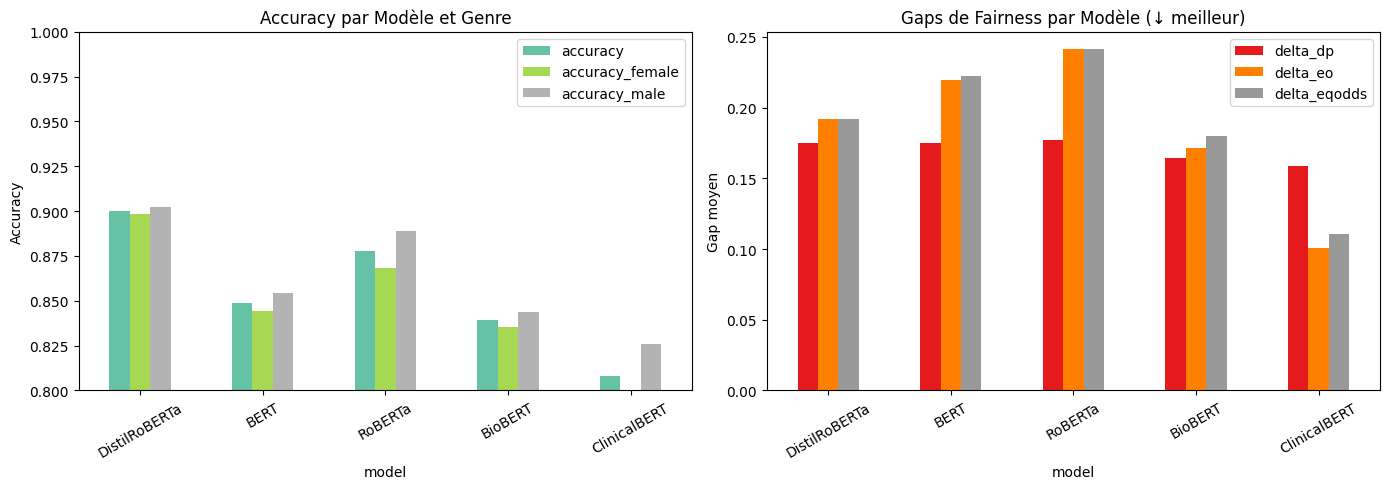

💾 Graphique sauvegardé: embedding_comparison.png


In [6]:
# Cellule 6: Tableau et visualisations
cols = ['accuracy', 'accuracy_female', 'accuracy_male', 'delta_dp', 'delta_eo', 'delta_eqodds']
print('\n📊 TABLEAU COMPARATIF:')
print(results_df[cols].round(4).to_string())

# Radar / bar plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
results_df[['accuracy','accuracy_female','accuracy_male']].plot(
    kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Accuracy par Modèle et Genre')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.8, 1.0)
axes[0].tick_params(axis='x', rotation=30)

# Fairness gaps
results_df[['delta_dp','delta_eo','delta_eqodds']].plot(
    kind='bar', ax=axes[1], colormap='Set1')
axes[1].set_title('Gaps de Fairness par Modèle (↓ meilleur)')
axes[1].set_ylabel('Gap moyen')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Graphique sauvegardé: embedding_comparison.png')


In [7]:
# Cellule 7: Sauvegarder résultats + meilleur modèle
results_df.to_csv('embedding_comparison_results.csv')

# Modèle avec meilleur compromis accuracy/fairness
# Score composite = accuracy - mean(gaps fairness)
results_df['composite_score'] = (
    results_df['accuracy'] -
    results_df[['delta_dp','delta_eo','delta_eqodds']].mean(axis=1)
)

best_model = results_df['composite_score'].idxmax()
print(f'\n🏆 MEILLEUR COMPROMIS ACCURACY/FAIRNESS: {best_model}')
print(results_df.loc[best_model, cols].round(4).to_string())

# Sauvegarder le nom du meilleur modèle pour notebook 04
MODELS_DICT = dict(MODELS)
best_model_id = {v: k for k, v in MODELS_DICT.items()}[best_model]
with open('best_embedding_model.json', 'w') as f:
    json.dump({'label': best_model, 'model_id': best_model_id}, f)

print(f'💾 Résultats sauvegardés: embedding_comparison_results.csv')
print(f'💾 Meilleur modèle sauvegardé: best_embedding_model.json')



🏆 MEILLEUR COMPROMIS ACCURACY/FAIRNESS: DistilRoBERTa
accuracy           0.9000
accuracy_female    0.8981
accuracy_male      0.9022
delta_dp           0.1751
delta_eo           0.1920
delta_eqodds       0.1921
💾 Résultats sauvegardés: embedding_comparison_results.csv
💾 Meilleur modèle sauvegardé: best_embedding_model.json
